


##  1. Tải và Khởi tạo Dữ liệu

## 1.1 Chi tiết các biến số (Data Dictionary)


| Biến | Ý nghĩa | Ghi chú |
| :--- | :--- | :--- |
| **PassengerId** | ID của hành khách | Số định danh duy nhất |
| **Survived** | Sống sót hay không | 0 = Không, 1 = Có |
| **Pclass** | Hạng vé (Ticket class) | 1 = Hạng nhất, 2 = Hạng nhì, 3 = Hạng ba |
| **Name** | Tên hành khách | |
| **Sex** | Giới tính | |
| **Age** | Tuổi | Tính theo năm |
| **SibSp** | Số anh chị em/vợ chồng trên tàu | |
| **Parch** | Số cha mẹ/con cái trên tàu | |
| **Ticket** | Số vé | |
| **Fare** | Giá vé | |
| **Cabin** | Số cabin | |
| **Embarked** | Cảng lên tàu | C = Cherbourg, Q = Queenstown, S = Southampton |

#1 load thư viện và mô tả bộ dữ liệu

In [ ]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load Titanic dataset từ seaborn
titanic = sns.load_dataset('titanic')

print("✅ Đã load dữ liệu Titanic thành công!")
print(f"📊 Kích thước dataset: {titanic.shape[0]} hàng, {titanic.shape[1]} cột")

# Hiển thị 10 dòng đầu
display(titanic.head(10))

✅ Đã load dữ liệu Titanic thành công!
📊 Kích thước dataset: 891 hàng, 15 cột


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


có 15 cột là do thư viện seaborn tạo thêm 2 cột là who và audit male

In [24]:
# Thống kê cho các biến số
display(titanic.describe())

# Thống kê cho các biến phân loại (chuỗi/phân nhóm)
display(titanic.describe(include=['object', 'category']))

,survived,pclass,age,sibsp,parch,fare,family_size
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


,sex,embarked,class,who,deck,embark_town,alive,age_group,family_category
count,891,889,891,891,203,889,891,714,891
unique,2,3,3,3,7,3,2,5,3
top,male,S,Third,man,C,Southampton,no,Trưởng thành (19-35),Đi một mình
freq,577,644,491,537,59,644,549,358,537


thêm các giá trị kiểu chữ vào count: Số lượng giá trị hiện có (không bị thiếu).
unique: Số lượng các giá trị khác nhau (duy nhất) trong cột đó.
top: Giá trị xuất hiện thường xuyên nhất.
freq: Tần suất xuất hiện của giá trị 'top' đó

### Giải thích các chỉ số thống kê mô tả:

1.  **Count (Số lượng):** Tổng số dòng có dữ liệu (không phải NaN). Ví dụ: `Age` có 714 dòng, nghĩa là có 177 dòng bị thiếu.
2.  **Mean (Trung bình):** Tổng giá trị chia cho số lượng. Ví dụ: Tỉ lệ sống sót trung bình là 0.38 (khoảng 38%).
3.  **Std (Độ lệch chuẩn):** Đo lường sự biến thiên. Con số này càng cao thì dữ liệu càng phân tán xa khỏi giá trị trung bình.
4.  **Min (Nhỏ nhất):** Giá trị thấp nhất được ghi nhận (ví dụ: tuổi nhỏ nhất là 0.42).
5.  **25% (Tứ phân vị dưới):** 25% dữ liệu có giá trị nhỏ hơn hoặc bằng số này.
6.  **50% (Trung vị - Median):** Điểm chính giữa của dữ liệu. Nếu xếp hàng từ thấp đến cao, người đứng giữa sẽ có giá trị này.
7.  **75% (Tứ phân vị trên):** 75% dữ liệu có giá trị nhỏ hơn hoặc bằng số này.
8.  **Max (Lớn nhất):** Giá trị cao nhất được ghi nhận (ví dụ: giá vé cao nhất là 512.32).

# 2. Tổng quan cấu trúc dữ liệu

In [5]:
# Thông tin tổng quan về dataset
print("="*70)
print("THÔNG TIN CẤU TRÚC DỮ LIỆU TITANIC")
print("="*70)

print("\n📊 Kích thước:")
print(f"   - Số hành khách: {titanic.shape[0]}")
print(f"   - Số biến: {titanic.shape[1]}")

print("\n📋 Thông tin các cột:")
print(titanic.info())

print("\n📊 Kiểu dữ liệu:")
for col in titanic.columns:
    print(f"   - {col:15s}: {str(titanic[col].dtype):10s} | Null: {titanic[col].isnull().sum():4d} ({titanic[col].isnull().sum()/len(titanic)*100:.1f}%)")

THÔNG TIN CẤU TRÚC DỮ LIỆU TITANIC

📊 Kích thước:
   - Số hành khách: 891
   - Số biến: 15

📋 Thông tin các cột:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4),

# 3. Thống kê mô tả - Biến số

In [6]:
# Thống kê mô tả cho các biến số
print("="*70)
print("THỐNG KÊ MÔ TẢ - BIẾN SỐ")
print("="*70)

numerical_cols = titanic.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n🔢 Các biến số: {numerical_cols}\n")

display(titanic[numerical_cols].describe().round(2))

print("\n💡 NHẬN XÉT:")
print(f"   - Tuổi trung bình: {titanic['age'].mean():.1f} năm (nhỏ nhất: {titanic['age'].min():.1f}, lớn nhất: {titanic['age'].max():.1f})")
print(f"   - Giá vé trung bình: ${titanic['fare'].mean():.2f} (max: ${titanic['fare'].max():.2f})")
print(f"   - Tỉ lệ sống sót: {titanic['survived'].mean()*100:.1f}%")

THỐNG KÊ MÔ TẢ - BIẾN SỐ

🔢 Các biến số: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']



,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33



💡 NHẬN XÉT:
   - Tuổi trung bình: 29.7 năm (nhỏ nhất: 0.4, lớn nhất: 80.0)
   - Giá vé trung bình: $32.20 (max: $512.33)
   - Tỉ lệ sống sót: 38.4%


#4. Thống kê mô tả - Biến phân loại

In [8]:
# Thống kê mô tả cho các biến phân loại
print("="*70)
print("THỐNG KÊ MÔ TẢ - BIẾN PHÂN LOẠI")
print("="*70)

categorical_cols = ['sex', 'pclass', 'embarked', 'who', 'deck', 'embark_town', 'alive', 'alone']

for col in categorical_cols:
    if col in titanic.columns:
        print(f"\n🏷️  {col.upper()}:")
        value_counts = titanic[col].value_counts(dropna=False)
        for idx, (val, count) in enumerate(value_counts.items(), 1):
            pct = count/len(titanic)*100
            print(f"   {idx}. {val}: {count} ({pct:.1f}%)")

THỐNG KÊ MÔ TẢ - BIẾN PHÂN LOẠI

🏷️  SEX:
   1. male: 577 (64.8%)
   2. female: 314 (35.2%)

🏷️  PCLASS:
   1. 3: 491 (55.1%)
   2. 1: 216 (24.2%)
   3. 2: 184 (20.7%)

🏷️  EMBARKED:
   1. S: 644 (72.3%)
   2. C: 168 (18.9%)
   3. Q: 77 (8.6%)
   4. nan: 2 (0.2%)

🏷️  WHO:
   1. man: 537 (60.3%)
   2. woman: 271 (30.4%)
   3. child: 83 (9.3%)

🏷️  DECK:
   1. nan: 688 (77.2%)
   2. C: 59 (6.6%)
   3. B: 47 (5.3%)
   4. D: 33 (3.7%)
   5. E: 32 (3.6%)
   6. A: 15 (1.7%)
   7. F: 13 (1.5%)
   8. G: 4 (0.4%)

🏷️  EMBARK_TOWN:
   1. Southampton: 644 (72.3%)
   2. Cherbourg: 168 (18.9%)
   3. Queenstown: 77 (8.6%)
   4. nan: 2 (0.2%)

🏷️  ALIVE:
   1. no: 549 (61.6%)
   2. yes: 342 (38.4%)

🏷️  ALONE:
   1. True: 537 (60.3%)
   2. False: 354 (39.7%)


#5. Phân tích giá trị thiếu (Missing Values)

PHÂN TÍCH GIÁ TRỊ THIẾU (MISSING VALUES)


,Column,Missing_Count,Missing_Percent
deck,deck,688,77.22
age,age,177,19.87
embarked,embarked,2,0.22
embark_town,embark_town,2,0.22


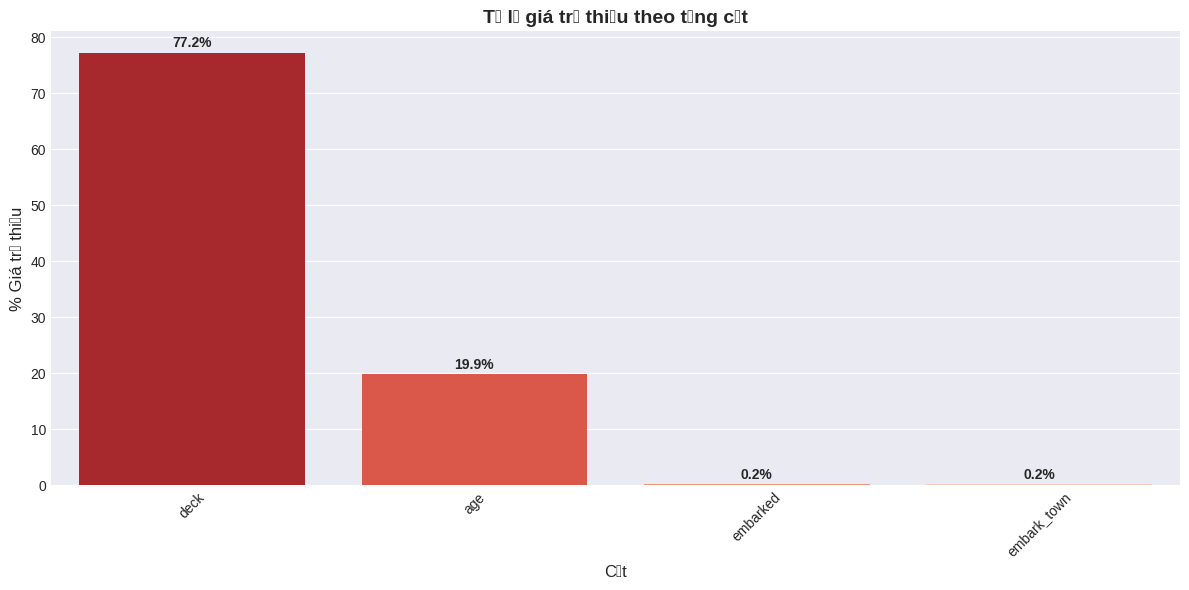

In [9]:
# Phân tích giá trị thiếu
print("="*70)
print("PHÂN TÍCH GIÁ TRỊ THIẾU (MISSING VALUES)")
print("="*70)

missing_data = pd.DataFrame({
    'Column': titanic.columns,
    'Missing_Count': titanic.isnull().sum(),
    'Missing_Percent': (titanic.isnull().sum() / len(titanic) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    display(missing_data)

    # Visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=missing_data, x='Column', y='Missing_Percent', ax=ax, palette='Reds_r')
    ax.set_title('Tỷ lệ giá trị thiếu theo từng cột', fontsize=14, fontweight='bold')
    ax.set_ylabel('% Giá trị thiếu', fontsize=12)
    ax.set_xlabel('Cột', fontsize=12)
    plt.xticks(rotation=45)
    for i, v in enumerate(missing_data['Missing_Percent']):
        ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ Không có giá trị thiếu trong dataset!")

cột embark_town do dữ liệu bên seaborn thêm vào bản chất chỉ là ghi rõ trên 3 địa điểm lên tàu

# 6. Phân bố biến mục tiêu - Tỉ lệ sống sót

PHÂN TÍCH TỈ LỆ SỐNG SÓT

📊 Tổng quan:
   - Không sống sót (0): 549 người (61.6%)
   - Sống sót (1): 342 người (38.4%)


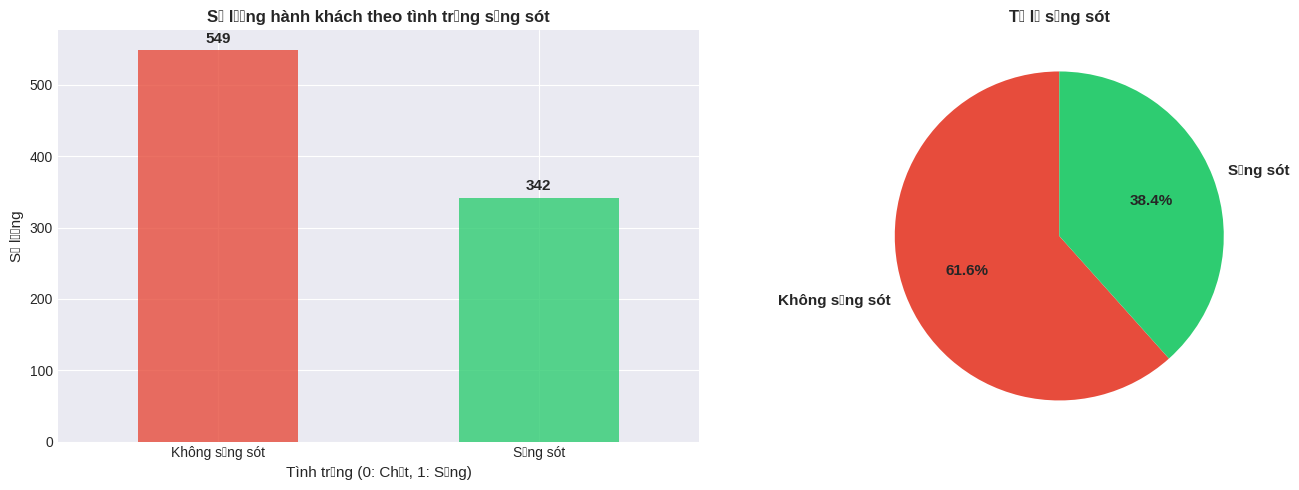

In [10]:
# Phân tích biến mục tiêu: Survived
print("="*70)
print("PHÂN TÍCH TỈ LỆ SỐNG SÓT")
print("="*70)

survival_counts = titanic['survived'].value_counts()
survival_pct = titanic['survived'].value_counts(normalize=True) * 100

print(f"\n📊 Tổng quan:")
print(f"   - Không sống sót (0): {survival_counts[0]} người ({survival_pct[0]:.1f}%)")
print(f"   - Sống sót (1): {survival_counts[1]} người ({survival_pct[1]:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1 = axes[0]
survival_counts.plot(kind='bar', ax=ax1, color=['#e74c3c', '#2ecc71'], alpha=0.8)
ax1.set_title('Số lượng hành khách theo tình trạng sống sót', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tình trạng (0: Chết, 1: Sống)', fontsize=11)
ax1.set_ylabel('Số lượng', fontsize=11)
ax1.set_xticklabels(['Không sống sót', 'Sống sót'], rotation=0)
for i, v in enumerate(survival_counts):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=11)

# Pie chart
ax2 = axes[1]
ax2.pie(survival_counts, labels=['Không sống sót', 'Sống sót'], autopct='%1.1f%%',
        colors=['#e74c3c', '#2ecc71'], startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Tỉ lệ sống sót', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#7. Phân tích theo Giới tính (Sex)

PHÂN TÍCH SỐNG SÓT THEO GIỚI TÍNH

📊 Tỉ lệ sống sót theo giới tính (%):



survived,0,1
sex,,
female,25.80,74.20
male,81.11,18.89



💡 NHẬN XÉT:
   - Male: 18.9% sống sót (109/577 người)
   - Female: 74.2% sống sót (233/314 người)


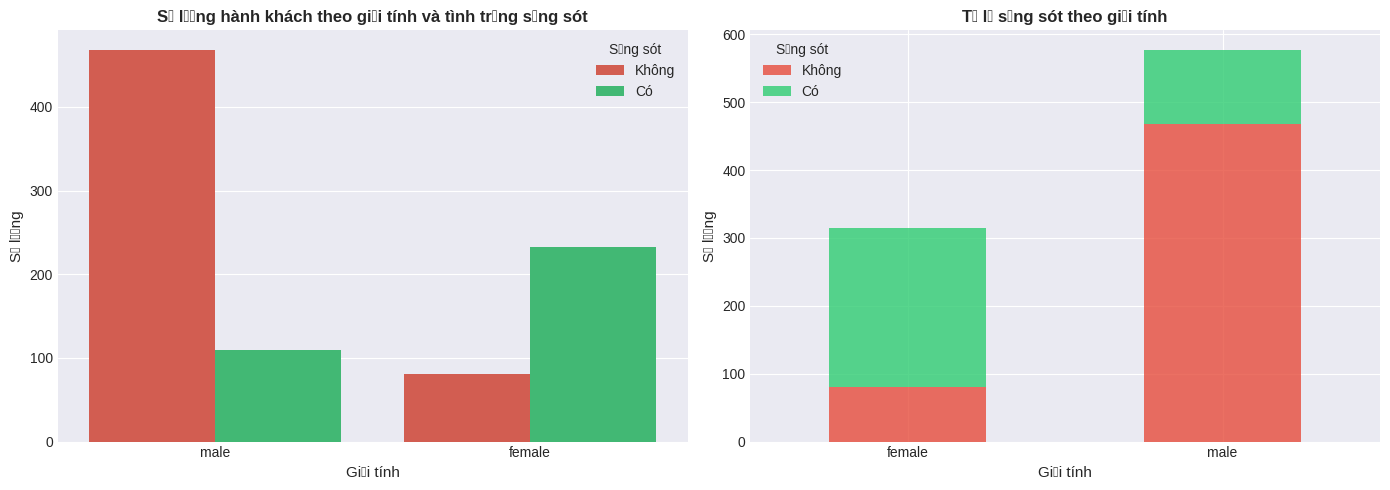

In [11]:
# Phân tích sống sót theo giới tính
print("="*70)
print("PHÂN TÍCH SỐNG SÓT THEO GIỚI TÍNH")
print("="*70)

sex_survival = pd.crosstab(titanic['sex'], titanic['survived'], normalize='index') * 100
print("\n📊 Tỉ lệ sống sót theo giới tính (%):\n")
display(sex_survival.round(2))

print(f"\n💡 NHẬN XÉT:")
for sex in titanic['sex'].unique():
    if pd.notna(sex):
        survival_rate = titanic[titanic['sex']==sex]['survived'].mean() * 100
        total = len(titanic[titanic['sex']==sex])
        survived = titanic[(titanic['sex']==sex) & (titanic['survived']==1)].shape[0]
        print(f"   - {sex.capitalize()}: {survival_rate:.1f}% sống sót ({survived}/{total} người)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax1 = axes[0]
sns.countplot(data=titanic, x='sex', hue='survived', ax=ax1, palette=['#e74c3c', '#2ecc71'])
ax1.set_title('Số lượng hành khách theo giới tính và tình trạng sống sót', fontsize=12, fontweight='bold')
ax1.set_xlabel('Giới tính', fontsize=11)
ax1.set_ylabel('Số lượng', fontsize=11)
ax1.legend(title='Sống sót', labels=['Không', 'Có'])

# Percentage stacked bar
ax2 = axes[1]
sex_survival_counts = pd.crosstab(titanic['sex'], titanic['survived'])
sex_survival_counts.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'], alpha=0.8)
ax2.set_title('Tỉ lệ sống sót theo giới tính', fontsize=12, fontweight='bold')
ax2.set_xlabel('Giới tính', fontsize=11)
ax2.set_ylabel('Số lượng', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Sống sót', labels=['Không', 'Có'])

plt.tight_layout()
plt.show()

# 8. Phân tích theo Hạng vé (Pclass)

PHÂN TÍCH SỐNG SÓT THEO HẠNG VÉ

📊 Tỉ lệ sống sót theo hạng vé (%):



survived,0,1
pclass,,
1,37.04,62.96
2,52.72,47.28
3,75.76,24.24



💡 NHẬN XÉT:
   - Hạng 1: 63.0% sống sót (136/216 người) - Giá vé TB: $84.15
   - Hạng 2: 47.3% sống sót (87/184 người) - Giá vé TB: $20.66
   - Hạng 3: 24.2% sống sót (119/491 người) - Giá vé TB: $13.68


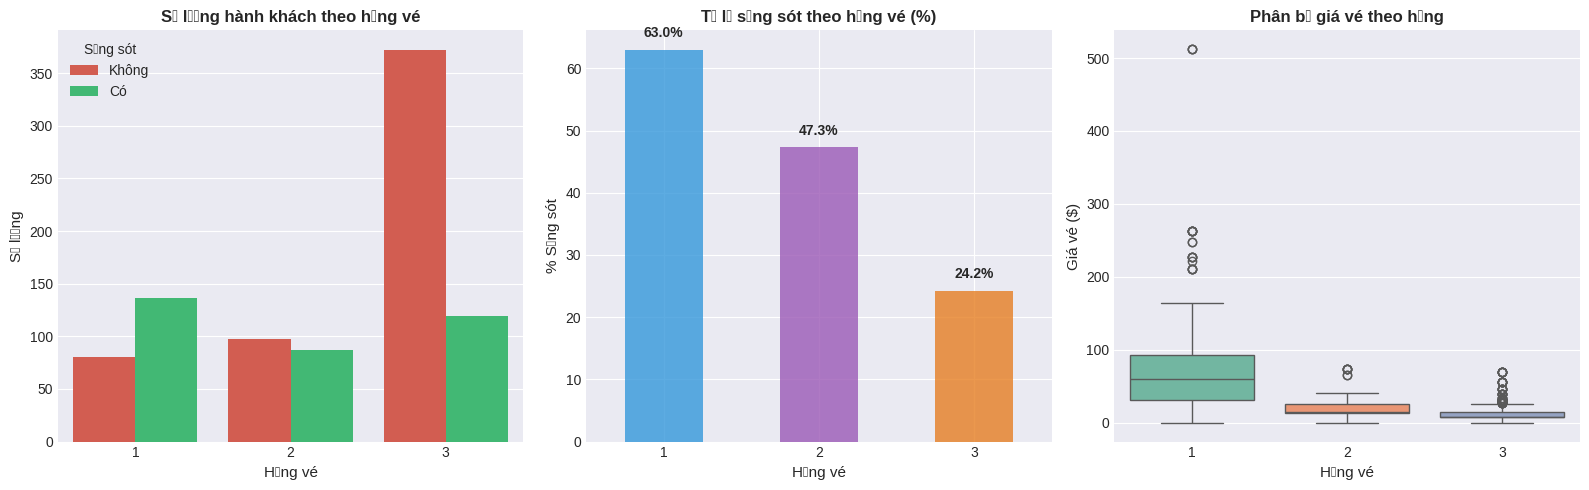

In [12]:
# Phân tích sống sót theo hạng vé
print("="*70)
print("PHÂN TÍCH SỐNG SÓT THEO HẠNG VÉ")
print("="*70)

pclass_survival = pd.crosstab(titanic['pclass'], titanic['survived'], normalize='index') * 100
print("\n📊 Tỉ lệ sống sót theo hạng vé (%):\n")
display(pclass_survival.round(2))

print(f"\n💡 NHẬN XÉT:")
for pclass in sorted(titanic['pclass'].unique()):
    if pd.notna(pclass):
        survival_rate = titanic[titanic['pclass']==pclass]['survived'].mean() * 100
        total = len(titanic[titanic['pclass']==pclass])
        survived = titanic[(titanic['pclass']==pclass) & (titanic['survived']==1)].shape[0]
        avg_fare = titanic[titanic['pclass']==pclass]['fare'].mean()
        print(f"   - Hạng {int(pclass)}: {survival_rate:.1f}% sống sót ({survived}/{total} người) - Giá vé TB: ${avg_fare:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Count plot
ax1 = axes[0]
sns.countplot(data=titanic, x='pclass', hue='survived', ax=ax1, palette=['#e74c3c', '#2ecc71'])
ax1.set_title('Số lượng hành khách theo hạng vé', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hạng vé', fontsize=11)
ax1.set_ylabel('Số lượng', fontsize=11)
ax1.legend(title='Sống sót', labels=['Không', 'Có'])

# Survival rate by class
ax2 = axes[1]
survival_by_class = titanic.groupby('pclass')['survived'].mean() * 100
survival_by_class.plot(kind='bar', ax=ax2, color=['#3498db', '#9b59b6', '#e67e22'], alpha=0.8)
ax2.set_title('Tỉ lệ sống sót theo hạng vé (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Hạng vé', fontsize=11)
ax2.set_ylabel('% Sống sót', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
for i, v in enumerate(survival_by_class):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Fare distribution by class
ax3 = axes[2]
sns.boxplot(data=titanic, x='pclass', y='fare', ax=ax3, palette='Set2')
ax3.set_title('Phân bố giá vé theo hạng', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hạng vé', fontsize=11)
ax3.set_ylabel('Giá vé ($)', fontsize=11)

plt.tight_layout()
plt.show()

# 9. Phân tích theo Tuổi (Age)

PHÂN TÍCH SỐNG SÓT THEO TUỔI

📊 Thống kê tuổi:
   - Tuổi trung bình: 29.70 năm
   - Tuổi trung vị: 28.00 năm
   - Tuổi nhỏ nhất: 0.42 năm
   - Tuổi lớn nhất: 80.00 năm
   - Giá trị thiếu: 177 (19.9%)

💡 Tỉ lệ sống sót theo nhóm tuổi:
   - Trẻ em (0-12): 58.0% (40/69 người)
   - Thanh niên (13-18): 42.9% (30/70 người)
   - Trưởng thành (19-35): 38.3% (137/358 người)
   - Trung niên (36-60): 40.0% (78/195 người)
   - Cao tuổi (60+): 22.7% (5/22 người)


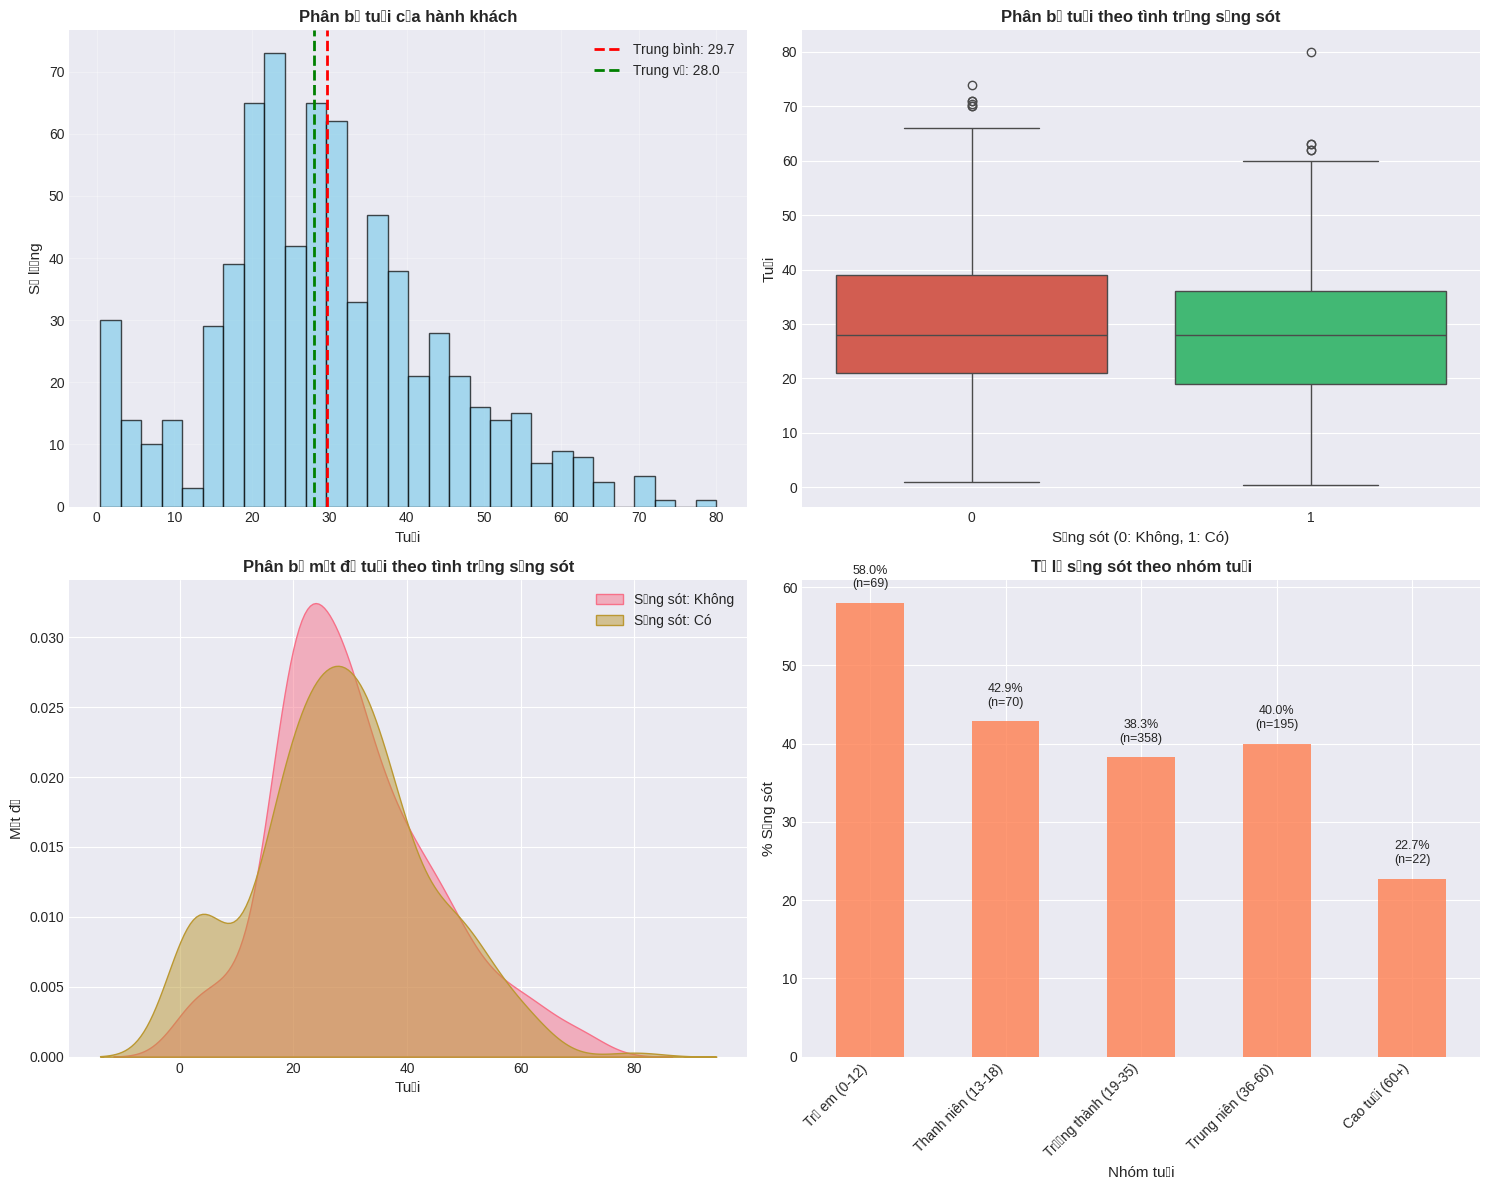

In [13]:
# Phân tích sống sót theo tuổi
print("="*70)
print("PHÂN TÍCH SỐNG SÓT THEO TUỔI")
print("="*70)

print(f"\n📊 Thống kê tuổi:")
print(f"   - Tuổi trung bình: {titanic['age'].mean():.2f} năm")
print(f"   - Tuổi trung vị: {titanic['age'].median():.2f} năm")
print(f"   - Tuổi nhỏ nhất: {titanic['age'].min():.2f} năm")
print(f"   - Tuổi lớn nhất: {titanic['age'].max():.2f} năm")
print(f"   - Giá trị thiếu: {titanic['age'].isnull().sum()} ({titanic['age'].isnull().sum()/len(titanic)*100:.1f}%)")

# Tạo các nhóm tuổi
titanic['age_group'] = pd.cut(titanic['age'], bins=[0, 12, 18, 35, 60, 100],
                               labels=['Trẻ em (0-12)', 'Thanh niên (13-18)', 'Trưởng thành (19-35)', 'Trung niên (36-60)', 'Cao tuổi (60+)'])

print(f"\n💡 Tỉ lệ sống sót theo nhóm tuổi:")
for age_group in titanic['age_group'].cat.categories:
    data = titanic[titanic['age_group']==age_group]
    if len(data) > 0:
        survival_rate = data['survived'].mean() * 100
        print(f"   - {age_group}: {survival_rate:.1f}% ({data['survived'].sum()}/{len(data)} người)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Age distribution
ax1 = axes[0, 0]
titanic['age'].hist(bins=30, ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(titanic['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Trung bình: {titanic["age"].mean():.1f}')
ax1.axvline(titanic['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Trung vị: {titanic["age"].median():.1f}')
ax1.set_title('Phân bố tuổi của hành khách', fontsize=12, fontweight='bold')
ax1.set_xlabel('Tuổi', fontsize=11)
ax1.set_ylabel('Số lượng', fontsize=11)
ax1.legend()
ax1.grid(alpha=0.3)

# Age by survival
ax2 = axes[0, 1]
sns.boxplot(data=titanic, x='survived', y='age', ax=ax2, palette=['#e74c3c', '#2ecc71'])
ax2.set_title('Phân bố tuổi theo tình trạng sống sót', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sống sót (0: Không, 1: Có)', fontsize=11)
ax2.set_ylabel('Tuổi', fontsize=11)

# Age distribution by survival (KDE)
ax3 = axes[1, 0]
for survived in [0, 1]:
    data = titanic[titanic['survived']==survived]['age'].dropna()
    sns.kdeplot(data=data, ax=ax3, label=f'Sống sót: {"Có" if survived else "Không"}', fill=True, alpha=0.5)
ax3.set_title('Phân bố mật độ tuổi theo tình trạng sống sót', fontsize=12, fontweight='bold')
ax3.set_xlabel('Tuổi', fontsize=11)
ax3.set_ylabel('Mật độ', fontsize=11)
ax3.legend()

# Survival rate by age group
ax4 = axes[1, 1]
age_group_survival = titanic.groupby('age_group', observed=True)['survived'].agg(['mean', 'count'])
age_group_survival['mean'] = age_group_survival['mean'] * 100
age_group_survival['mean'].plot(kind='bar', ax=ax4, color='coral', alpha=0.8)
ax4.set_title('Tỉ lệ sống sót theo nhóm tuổi', fontsize=12, fontweight='bold')
ax4.set_xlabel('Nhóm tuổi', fontsize=11)
ax4.set_ylabel('% Sống sót', fontsize=11)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
for i, (idx, row) in enumerate(age_group_survival.iterrows()):
    ax4.text(i, row['mean'] + 2, f"{row['mean']:.1f}%\n(n={int(row['count'])})", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 10. Phân tích gia đình (SibSp, Parch)

PHÂN TÍCH SỐNG SÓT THEO GIA ĐÌNH

👨‍👩‍👧‍👦 Thông tin gia đình:
   - SibSp (Anh chị em/Vợ chồng): Trung bình 0.52, Max: 8
   - Parch (Bố mẹ/Con cái): Trung bình 0.38, Max: 6
   - Đi một mình (alone): 537 người (60.3%)

💡 Tỉ lệ sống sót theo kích thước gia đình:
   - Đi một mình: 30.4% (163/537 người)
   - Gia đình nhỏ (2-4): 57.9% (169/292 người)
   - Gia đình lớn (5+): 16.1% (10/62 người)


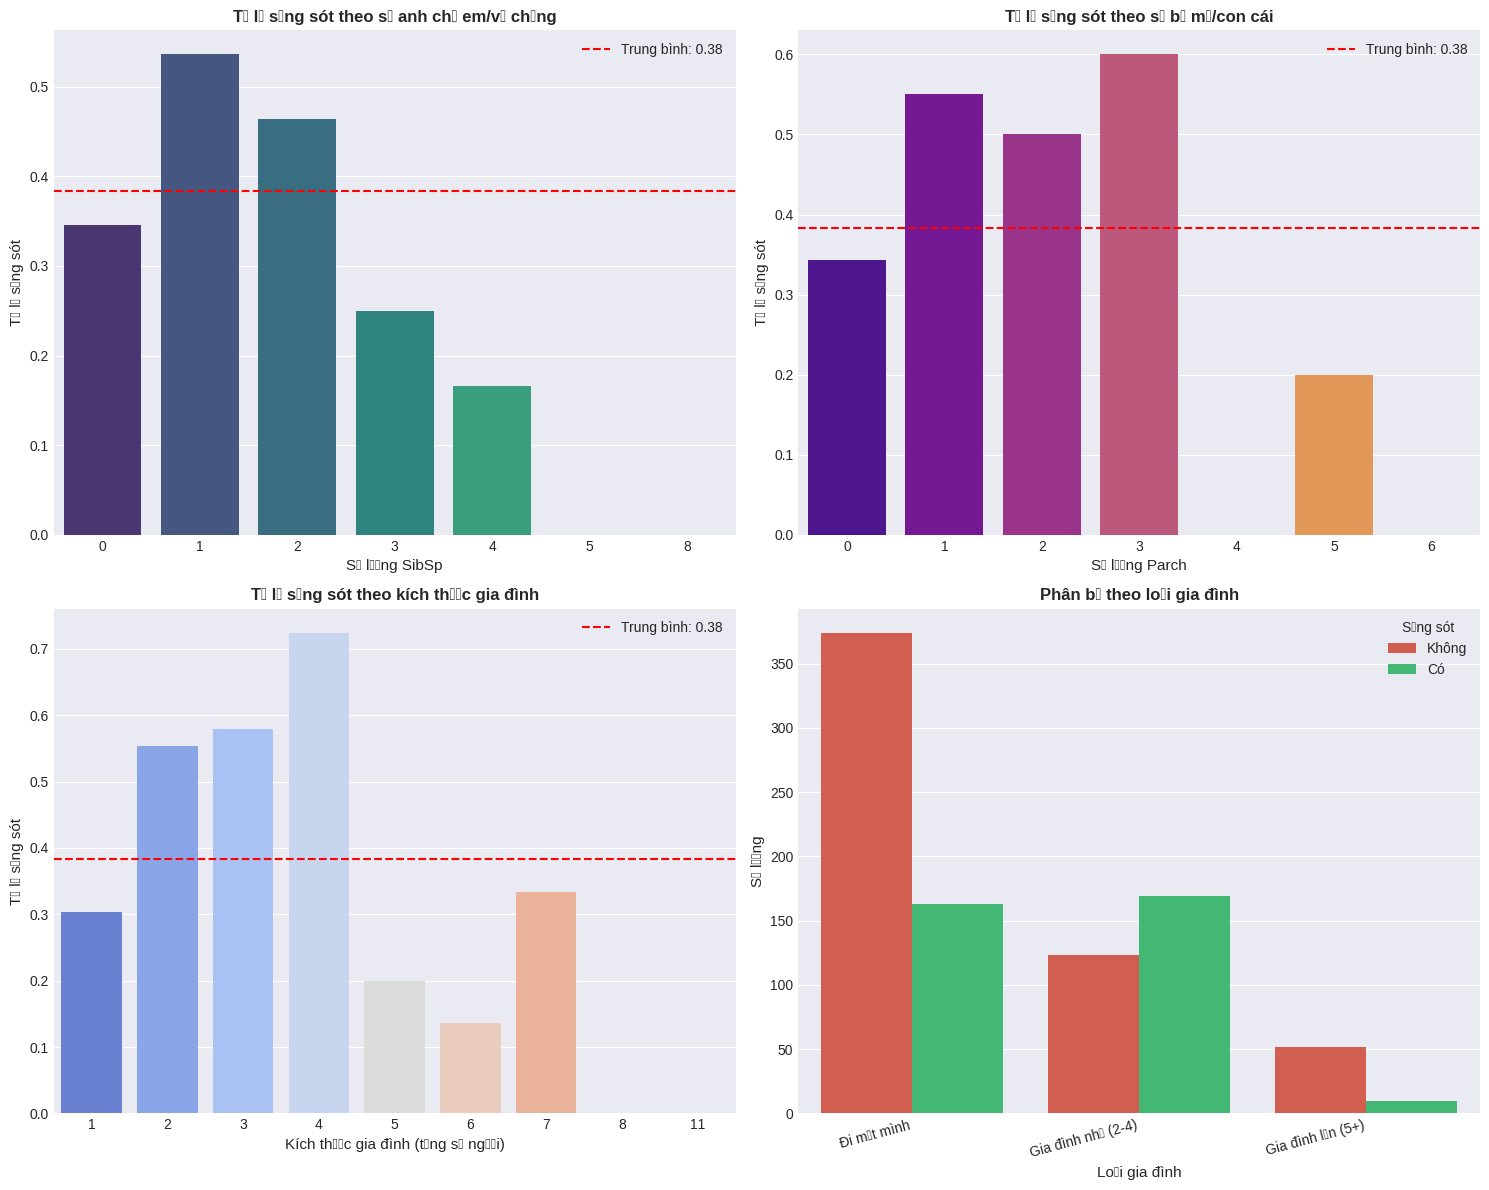

In [14]:
# Phân tích sống sót theo kích thước gia đình
print("="*70)
print("PHÂN TÍCH SỐNG SÓT THEO GIA ĐÌNH")
print("="*70)

print("\n👨‍👩‍👧‍👦 Thông tin gia đình:")
print(f"   - SibSp (Anh chị em/Vợ chồng): Trung bình {titanic['sibsp'].mean():.2f}, Max: {titanic['sibsp'].max()}")
print(f"   - Parch (Bố mẹ/Con cái): Trung bình {titanic['parch'].mean():.2f}, Max: {titanic['parch'].max()}")
print(f"   - Đi một mình (alone): {titanic['alone'].sum()} người ({titanic['alone'].sum()/len(titanic)*100:.1f}%)")

# Tạo biến kích thước gia đình
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['family_category'] = pd.cut(titanic['family_size'], bins=[0, 1, 4, 20],
                                     labels=['Đi một mình', 'Gia đình nhỏ (2-4)', 'Gia đình lớn (5+)'])

print(f"\n💡 Tỉ lệ sống sót theo kích thước gia đình:")
for category in titanic['family_category'].cat.categories:
    data = titanic[titanic['family_category']==category]
    if len(data) > 0:
        survival_rate = data['survived'].mean() * 100
        print(f"   - {category}: {survival_rate:.1f}% ({data['survived'].sum()}/{len(data)} người)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# SibSp vs Survival
ax1 = axes[0, 0]
sns.barplot(data=titanic, x='sibsp', y='survived', ax=ax1, palette='viridis', errorbar=None)
ax1.set_title('Tỉ lệ sống sót theo số anh chị em/vợ chồng', fontsize=12, fontweight='bold')
ax1.set_xlabel('Số lượng SibSp', fontsize=11)
ax1.set_ylabel('Tỉ lệ sống sót', fontsize=11)
ax1.axhline(y=titanic['survived'].mean(), color='red', linestyle='--', label=f'Trung bình: {titanic["survived"].mean():.2f}')
ax1.legend()

# Parch vs Survival
ax2 = axes[0, 1]
sns.barplot(data=titanic, x='parch', y='survived', ax=ax2, palette='plasma', errorbar=None)
ax2.set_title('Tỉ lệ sống sót theo số bố mẹ/con cái', fontsize=12, fontweight='bold')
ax2.set_xlabel('Số lượng Parch', fontsize=11)
ax2.set_ylabel('Tỉ lệ sống sót', fontsize=11)
ax2.axhline(y=titanic['survived'].mean(), color='red', linestyle='--', label=f'Trung bình: {titanic["survived"].mean():.2f}')
ax2.legend()

# Family size vs Survival
ax3 = axes[1, 0]
sns.barplot(data=titanic, x='family_size', y='survived', ax=ax3, palette='coolwarm', errorbar=None)
ax3.set_title('Tỉ lệ sống sót theo kích thước gia đình', fontsize=12, fontweight='bold')
ax3.set_xlabel('Kích thước gia đình (tổng số người)', fontsize=11)
ax3.set_ylabel('Tỉ lệ sống sót', fontsize=11)
ax3.axhline(y=titanic['survived'].mean(), color='red', linestyle='--', label=f'Trung bình: {titanic["survived"].mean():.2f}')
ax3.legend()

# Family category distribution
ax4 = axes[1, 1]
sns.countplot(data=titanic, x='family_category', hue='survived', ax=ax4, palette=['#e74c3c', '#2ecc71'])
ax4.set_title('Phân bố theo loại gia đình', fontsize=12, fontweight='bold')
ax4.set_xlabel('Loại gia đình', fontsize=11)
ax4.set_ylabel('Số lượng', fontsize=11)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=15, ha='right')
ax4.legend(title='Sống sót', labels=['Không', 'Có'])

plt.tight_layout()
plt.show()

# 11. Phân tích kết hợp: Giới tính x Hạng vé

PHÂN TÍCH KẾT HỢP: GIỚI TÍNH X HẠNG VÉ

📊 Tỉ lệ sống sót (%) theo giới tính và hạng vé:



pclass,1,2,3
sex,,,
female,96.81,92.11,50.00
male,36.89,15.74,13.54



💡 NHẬN XÉT CHI TIẾT:

Male:
   - Hạng 1: 36.9% (45/122)
   - Hạng 2: 15.7% (17/108)
   - Hạng 3: 13.5% (47/347)

Female:
   - Hạng 1: 96.8% (91/94)
   - Hạng 2: 92.1% (70/76)
   - Hạng 3: 50.0% (72/144)


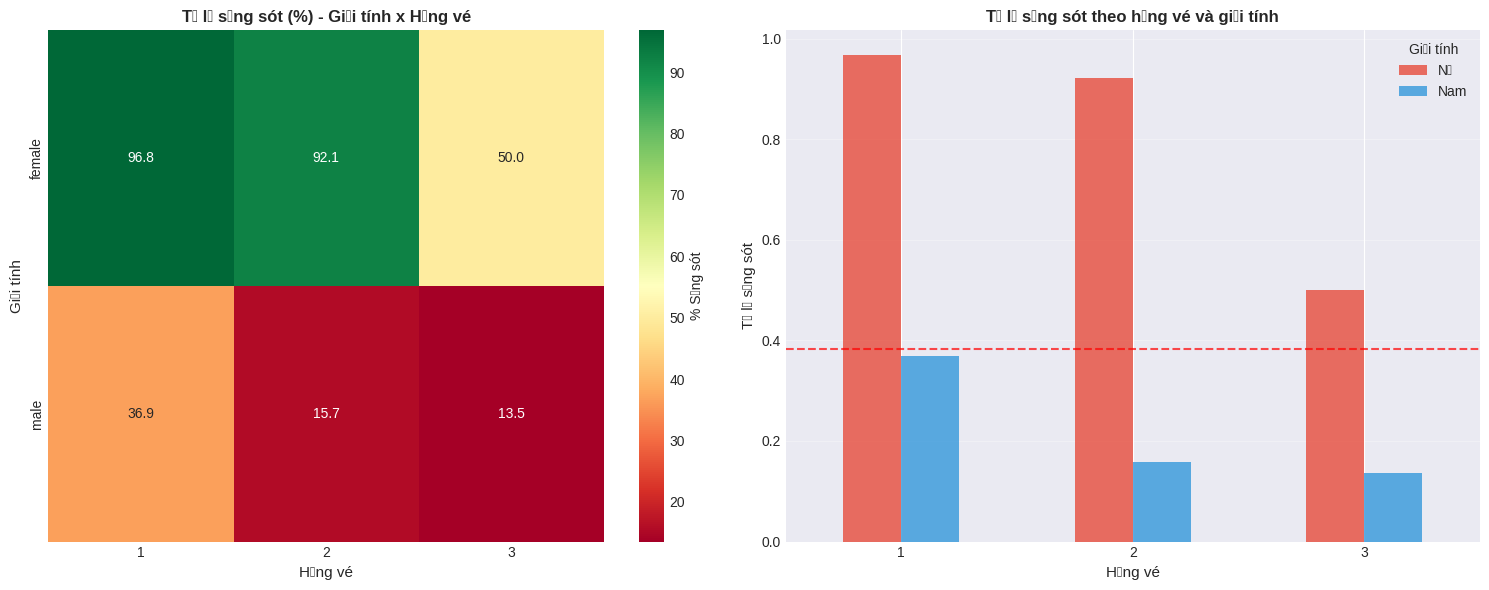

In [15]:
# Phân tích kết hợp giới tính và hạng vé
print("="*70)
print("PHÂN TÍCH KẾT HỢP: GIỚI TÍNH X HẠNG VÉ")
print("="*70)

# Pivot table
pivot_sex_class = titanic.pivot_table(values='survived', index='sex', columns='pclass', aggfunc='mean') * 100
print("\n📊 Tỉ lệ sống sót (%) theo giới tính và hạng vé:\n")
display(pivot_sex_class.round(2))

print(f"\n💡 NHẬN XÉT CHI TIẾT:")
for sex in titanic['sex'].unique():
    if pd.notna(sex):
        print(f"\n{sex.capitalize()}:")
        for pclass in sorted(titanic['pclass'].unique()):
            data = titanic[(titanic['sex']==sex) & (titanic['pclass']==pclass)]
            if len(data) > 0:
                survival_rate = data['survived'].mean() * 100
                survived = data['survived'].sum()
                total = len(data)
                print(f"   - Hạng {int(pclass)}: {survival_rate:.1f}% ({survived}/{total})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap
ax1 = axes[0]
sns.heatmap(pivot_sex_class, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax1, cbar_kws={'label': '% Sống sót'})
ax1.set_title('Tỉ lệ sống sót (%) - Giới tính x Hạng vé', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hạng vé', fontsize=11)
ax1.set_ylabel('Giới tính', fontsize=11)

# Grouped bar chart
ax2 = axes[1]
titanic.groupby(['pclass', 'sex'])['survived'].mean().unstack().plot(kind='bar', ax=ax2,
                                                                        color=['#e74c3c', '#3498db'], alpha=0.8)
ax2.set_title('Tỉ lệ sống sót theo hạng vé và giới tính', fontsize=12, fontweight='bold')
ax2.set_xlabel('Hạng vé', fontsize=11)
ax2.set_ylabel('Tỉ lệ sống sót', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Giới tính', labels=['Nữ', 'Nam'])
ax2.axhline(y=titanic['survived'].mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'TB chung: {titanic["survived"].mean():.2f}')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

12. Phân tích điểm lên tàu (Embarked)

PHÂN TÍCH THEO ĐIỂM LÊN TÀU (EMBARKED)

😢 Các cảng:
   - C: Cherbourg (Pháp)
   - Q: Queenstown (Ireland)
   - S: Southampton (Anh)

📊 Thống kê theo cảng:



,Tổng số,Sống sót,Tỉ lệ SS,Giá vé TB,Hạng phổ biến
embarked,,,,,
C,168,93,55.36,59.95,1
Q,77,30,38.96,13.28,3
S,644,217,33.70,27.08,3



💡 NHẬN XÉT:
   - Cảng C: 55.4% sống sót (93/168)
   - Cảng Q: 39.0% sống sót (30/77)
   - Cảng S: 33.7% sống sót (217/644)


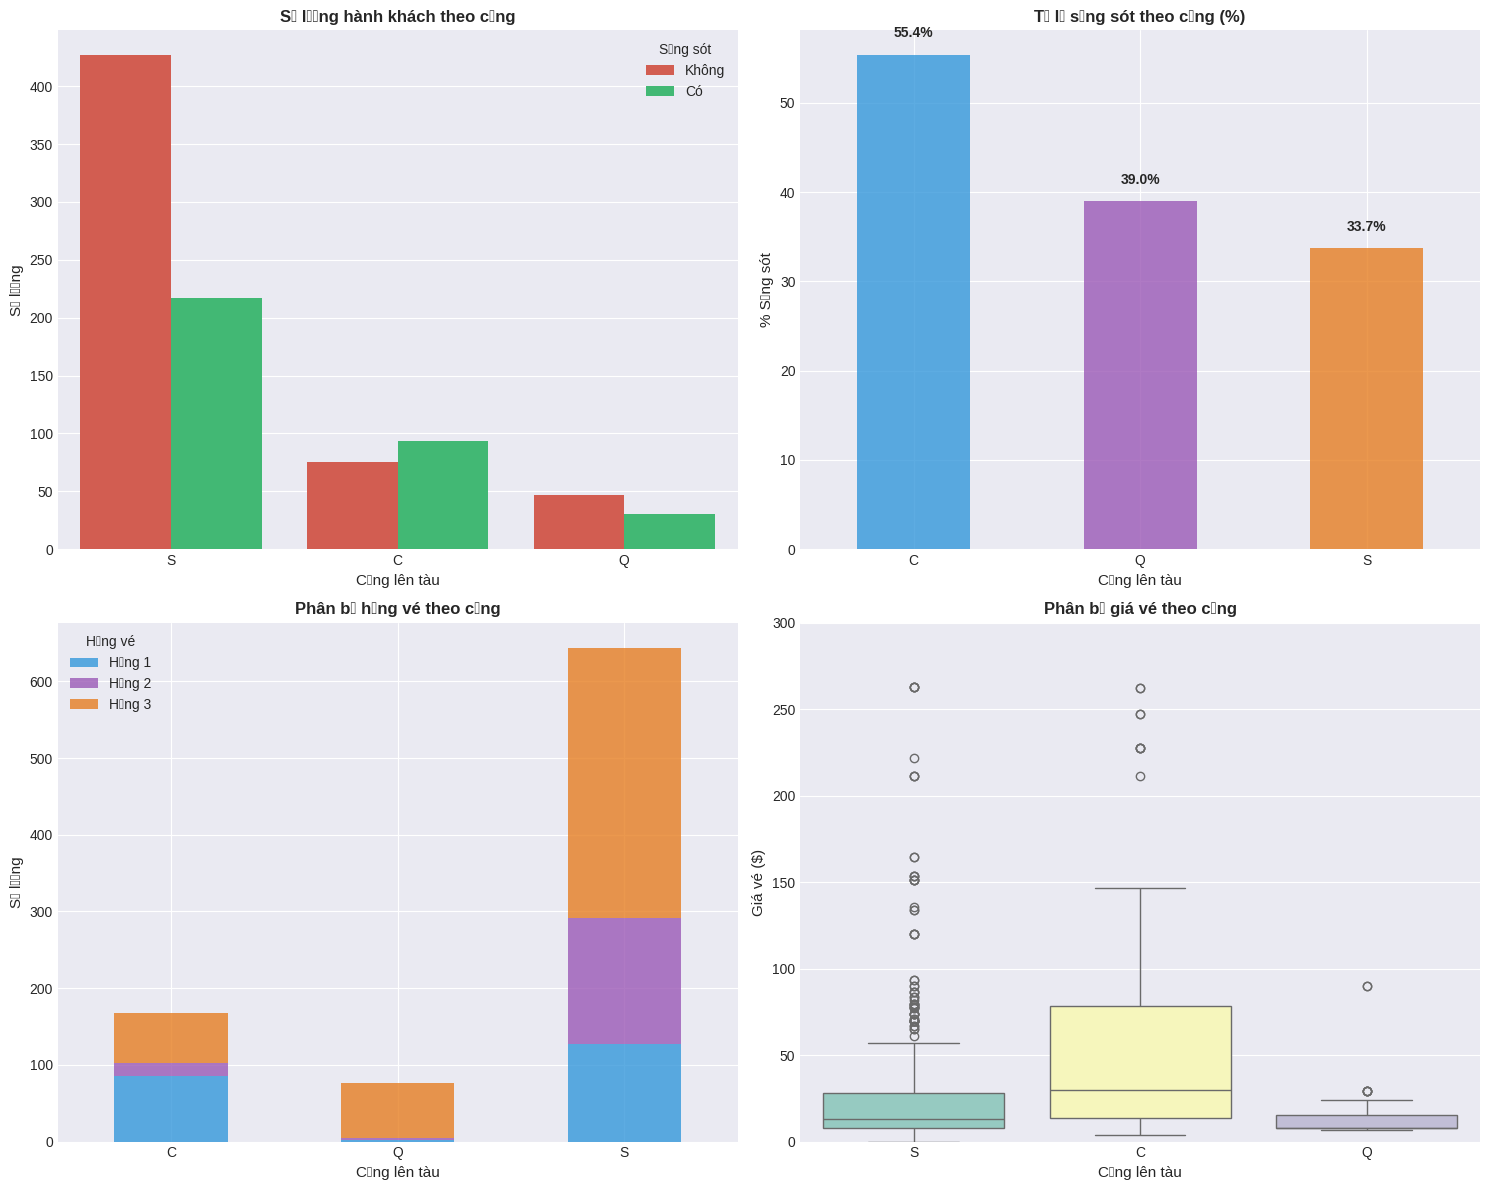

In [16]:
# Phân tích theo điểm lên tàu
print("="*70)
print("PHÂN TÍCH THEO ĐIỂM LÊN TÀU (EMBARKED)")
print("="*70)

print("\n😢 Các cảng:")
print("   - C: Cherbourg (Pháp)")
print("   - Q: Queenstown (Ireland)")
print("   - S: Southampton (Anh)")

embarked_stats = titanic.groupby('embarked').agg({
    'survived': ['count', 'sum', 'mean'],
    'fare': 'mean',
    'pclass': lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan
})
embarked_stats.columns = ['Tổng số', 'Sống sót', 'Tỉ lệ SS', 'Giá vé TB', 'Hạng phổ biến']
embarked_stats['Tỉ lệ SS'] = (embarked_stats['Tỉ lệ SS'] * 100).round(2)
embarked_stats['Giá vé TB'] = embarked_stats['Giá vé TB'].round(2)

print("\n📊 Thống kê theo cảng:\n")
display(embarked_stats)

print(f"\n💡 NHẬN XÉT:")
for port in ['C', 'Q', 'S']:
    data = titanic[titanic['embarked']==port]
    if len(data) > 0:
        survival_rate = data['survived'].mean() * 100
        print(f"   - Cảng {port}: {survival_rate:.1f}% sống sót ({data['survived'].sum()}/{len(data)})")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Count by embarked
ax1 = axes[0, 0]
sns.countplot(data=titanic, x='embarked', hue='survived', ax=ax1, palette=['#e74c3c', '#2ecc71'])
ax1.set_title('Số lượng hành khách theo cảng', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cảng lên tàu', fontsize=11)
ax1.set_ylabel('Số lượng', fontsize=11)
ax1.legend(title='Sống sót', labels=['Không', 'Có'])

# Survival rate by embarked
ax2 = axes[0, 1]
embarked_survival = titanic.groupby('embarked')['survived'].mean() * 100
embarked_survival.plot(kind='bar', ax=ax2, color=['#3498db', '#9b59b6', '#e67e22'], alpha=0.8)
ax2.set_title('Tỉ lệ sống sót theo cảng (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cảng lên tàu', fontsize=11)
ax2.set_ylabel('% Sống sót', fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
for i, v in enumerate(embarked_survival):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Pclass distribution by embarked
ax3 = axes[1, 0]
pd.crosstab(titanic['embarked'], titanic['pclass']).plot(kind='bar', stacked=True, ax=ax3,
                                                           color=['#3498db', '#9b59b6', '#e67e22'], alpha=0.8)
ax3.set_title('Phân bố hạng vé theo cảng', fontsize=12, fontweight='bold')
ax3.set_xlabel('Cảng lên tàu', fontsize=11)
ax3.set_ylabel('Số lượng', fontsize=11)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.legend(title='Hạng vé', labels=['Hạng 1', 'Hạng 2', 'Hạng 3'])

# Fare by embarked
ax4 = axes[1, 1]
sns.boxplot(data=titanic, x='embarked', y='fare', ax=ax4, palette='Set3')
ax4.set_title('Phân bố giá vé theo cảng', fontsize=12, fontweight='bold')
ax4.set_xlabel('Cảng lên tàu', fontsize=11)
ax4.set_ylabel('Giá vé ($)', fontsize=11)
ax4.set_ylim(0, 300)

plt.tight_layout()
plt.show()

# 13. Ma trận tương quan (Correlation Matrix)

PHÂN TÍCH TƯƠNG QUAN GIỮA CÁC BIẾN

📊 Ma trận tương quan:



,survived,pclass,age,sibsp,parch,fare,family_size
survived,1.000,-0.338,-0.077,-0.035,0.082,0.257,0.017
pclass,-0.338,1.000,-0.369,0.083,0.018,-0.549,0.066
age,-0.077,-0.369,1.000,-0.308,-0.189,0.096,-0.302
sibsp,-0.035,0.083,-0.308,1.000,0.415,0.160,0.891
parch,0.082,0.018,-0.189,0.415,1.000,0.216,0.783
fare,0.257,-0.549,0.096,0.160,0.216,1.000,0.217
family_size,0.017,0.066,-0.302,0.891,0.783,0.217,1.000



💡 Tương quan với biến mục tiêu 'Survived':

   - fare           :  0.257 (Trung bình - ↑ Tăng khả năng sống sót)
   - parch          :  0.082 (Yếu - ↑ Tăng khả năng sống sót)
   - family_size    :  0.017 (Yếu - ↑ Tăng khả năng sống sót)
   - sibsp          : -0.035 (Yếu - ↓ Giảm khả năng sống sót)
   - age            : -0.077 (Yếu - ↓ Giảm khả năng sống sót)
   - pclass         : -0.338 (Mạnh - ↓ Giảm khả năng sống sót)


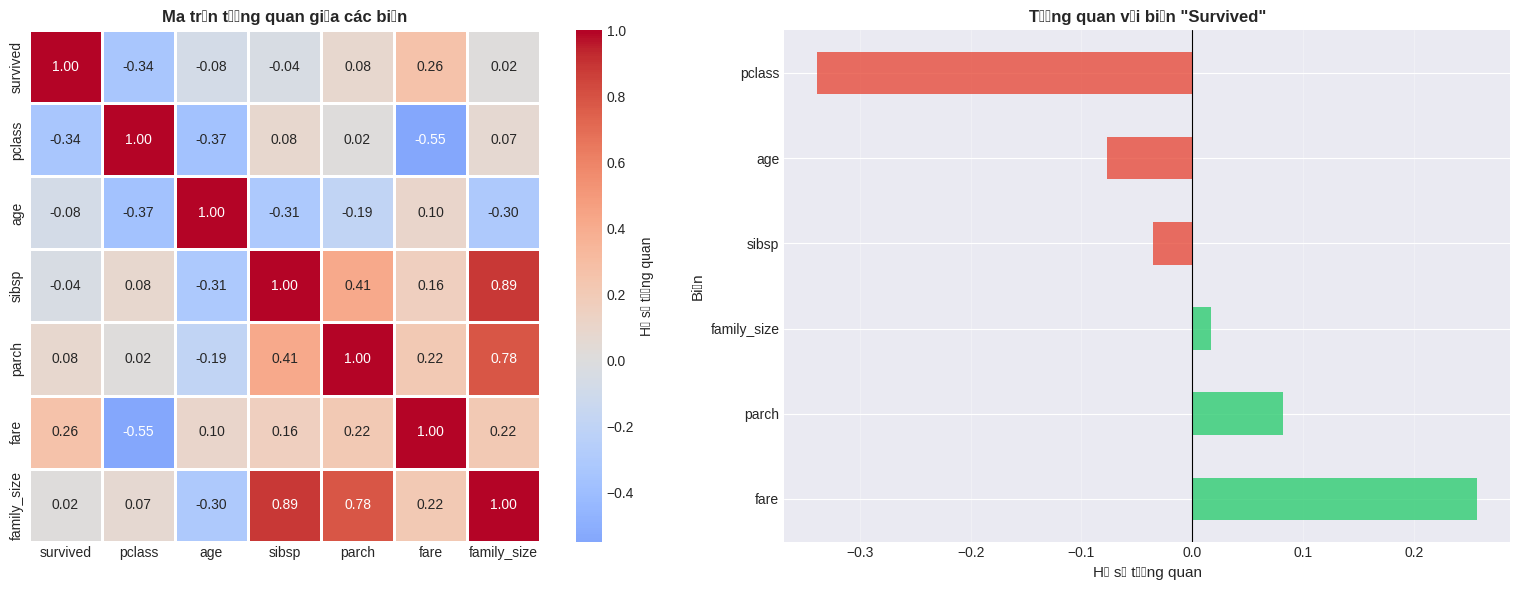

In [17]:
# Phân tích tương quan giữa các biến số
print("="*70)
print("PHÂN TÍCH TƯƠNG QUAN GIỮA CÁC BIẾN")
print("="*70)

# Chọn các biến số quan trọng
numerical_features = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']
corr_data = titanic[numerical_features].corr()

print("\n📊 Ma trận tương quan:\n")
display(corr_data.round(3))

# Tìm các tương quan mạnh với 'survived'
survival_corr = corr_data['survived'].sort_values(ascending=False)
print("\n💡 Tương quan với biến mục tiêu 'Survived':\n")
for feature, corr_val in survival_corr.items():
    if feature != 'survived':
        direction = "↑ Tăng" if corr_val > 0 else "↓ Giảm"
        strength = "Mạnh" if abs(corr_val) > 0.3 else "Trung bình" if abs(corr_val) > 0.15 else "Yếu"
        print(f"   - {feature:15s}: {corr_val:6.3f} ({strength} - {direction} khả năng sống sót)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
ax1 = axes[0]
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Hệ sổ tương quan'}, ax=ax1)
ax1.set_title('Ma trận tương quan giữa các biến', fontsize=12, fontweight='bold')

# Bar chart of correlation with survived
ax2 = axes[1]
survival_corr_plot = survival_corr.drop('survived')
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in survival_corr_plot]
survival_corr_plot.plot(kind='barh', ax=ax2, color=colors, alpha=0.8)
ax2.set_title('Tương quan với biến "Survived"', fontsize=12, fontweight='bold')
ax2.set_xlabel('Hệ sổ tương quan', fontsize=11)
ax2.set_ylabel('Biến', fontsize=11)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [18]:
# Tóm tắt các insights chính
print("="*70)
print("TÓM TẮT INSIGHTS VÀ KẾT LUẬN")
print("="*70)

print("\n📊 THỐNG KÊ TỔNG QUAN:")
print(f"   - Tổng số hành khách: {len(titanic)}")
print(f"   - Số người sống sót: {titanic['survived'].sum()} ({titanic['survived'].mean()*100:.1f}%)")
print(f"   - Số người không sống sót: {len(titanic) - titanic['survived'].sum()} ({(1-titanic['survived'].mean())*100:.1f}%)")

print("\n🔑 CÁC YẾbU TỐ ẢNH HƯỜNG CHÍNH:")

print("\n1️⃣ GIỚI TÍNH (Yếu tố mạnh nhất):")
for sex in ['female', 'male']:
    data = titanic[titanic['sex']==sex]
    survival_rate = data['survived'].mean() * 100
    print(f"   - {sex.capitalize()}: {survival_rate:.1f}% sống sót")
print("   ➡️ Nữ giới có tỉ lệ sống sót CAO HƠN ĐÁNG KỂ (chính sách 'phụ nữ và trẻ em trước')")

print("\n2️⃣ HẠNG VÉ (Phản ánh địa vị kinh tế):")
for pclass in sorted(titanic['pclass'].unique()):
    data = titanic[titanic['pclass']==pclass]
    survival_rate = data['survived'].mean() * 100
    print(f"   - Hạng {int(pclass)}: {survival_rate:.1f}% sống sót")
print("   ➡️ Hạng vé CAO HƠN (giàu hơn) có khả năng sống sót TỐT HƠN")

print("\n3️⃣ TUỔI:")
print(f"   - Tuổi trung bình sống sót: {titanic[titanic['survived']==1]['age'].mean():.1f} năm")
print(f"   - Tuổi trung bình không sống sót: {titanic[titanic['survived']==0]['age'].mean():.1f} năm")
print("   ➡️ Trẻ em có tỉ lệ sống sót CAO HƠN (chính sách 'phụ nữ và trẻ em trước')")

print("\n4️⃣ KÍCH THƯỚC GIA ĐÌNH:")
for cat in titanic['family_category'].cat.categories:
    data = titanic[titanic['family_category']==cat]
    if len(data) > 0:
        survival_rate = data['survived'].mean() * 100
        print(f"   - {cat}: {survival_rate:.1f}% sống sót")
print("   ➡️ Gia đình NHỎ (2-4 người) có tỉ lệ sống sót TỐT NHẤT")

print("\n🎯 KẾT LUẬN CHO MACHINE LEARNING:")
print("\n   🟢 Biến quan trọng nhất (theo thứ tự):")
print("      1. Sex (giới tính)")
print("      2. Pclass (hạng vé)")
print("      3. Age (tuổi)")
print("      4. Family_size (kích thước gia đình)")
print("      5. Fare (giá vé)")
print("      6. Embarked (điểm lên tàu)")

print("\n   🟡 Các vấn đề cần xử lý:")
print("      - Age: Thiếu ~20% giá trị (cần imputation)")
print("      - Cabin: Thiếu ~77% giá trị (có thể bỏ hoặc tạo biến 'has_cabin')")
print("      - Embarked: Thiếu 2 giá trị (có thể lấp bằng mode)")

print("\n   🔵 Feature Engineering gợi ý:")
print("      - Tạo biến 'Title' từ Name (Mr, Mrs, Miss, Master, etc.)")
print("      - Tạo biến 'Is_Child' (tuổi < 12)")
print("      - Tạo biến 'Fare_Per_Person' (fare / family_size)")
print("      - Tạo biến 'Deck' từ Cabin (lấy ký tự đầu tiên)")
print("      - One-hot encoding cho các biến categorical")

print("\n" + "="*70)
print("✅ HOÀN THÀNH PHÂN TÍCH EDA CHI TIẾT BỘ DỮ LIỆU TITANIC!")
print("="*70)

TÓM TẮT INSIGHTS VÀ KẾT LUẬN

📊 THỐNG KÊ TỔNG QUAN:
   - Tổng số hành khách: 891
   - Số người sống sót: 342 (38.4%)
   - Số người không sống sót: 549 (61.6%)

🔑 CÁC YẾbU TỐ ẢNH HƯỜNG CHÍNH:

1️⃣ GIỚI TÍNH (Yếu tố mạnh nhất):
   - Female: 74.2% sống sót
   - Male: 18.9% sống sót
   ➡️ Nữ giới có tỉ lệ sống sót CAO HƠN ĐÁNG KỂ (chính sách 'phụ nữ và trẻ em trước')

2️⃣ HẠNG VÉ (Phản ánh địa vị kinh tế):
   - Hạng 1: 63.0% sống sót
   - Hạng 2: 47.3% sống sót
   - Hạng 3: 24.2% sống sót
   ➡️ Hạng vé CAO HƠN (giàu hơn) có khả năng sống sót TỐT HƠN

3️⃣ TUỔI:
   - Tuổi trung bình sống sót: 28.3 năm
   - Tuổi trung bình không sống sót: 30.6 năm
   ➡️ Trẻ em có tỉ lệ sống sót CAO HƠN (chính sách 'phụ nữ và trẻ em trước')

4️⃣ KÍCH THƯỚC GIA ĐÌNH:
   - Đi một mình: 30.4% sống sót
   - Gia đình nhỏ (2-4): 57.9% sống sót
   - Gia đình lớn (5+): 16.1% sống sót
   ➡️ Gia đình NHỎ (2-4 người) có tỉ lệ sống sót TỐT NHẤT

🎯 KẾT LUẬN CHO MACHINE LEARNING:

   🟢 Biến quan trọng nhất (theo thứ tự):
  

### 14. Miêu tả chi tiết bộ dữ liệu

In [22]:
# Thống kê tổng quát cho các biến số (Numerical)
print("--- Thống kê các biến số ---")
display(titanic.describe())

# Thống kê tổng quát cho các biến phân loại (Categorical/Object)
print("\n--- Thống kê các biến phân loại ---")
display(titanic.describe(include=['object', 'category', 'bool']))

--- Thống kê các biến số ---


,survived,pclass,age,sibsp,parch,fare,family_size
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000



--- Thống kê các biến phân loại ---


,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_group,family_category
count,891,889,891,891,891,203,889,891,891,714,891
unique,2,3,3,3,2,7,3,2,2,5,3
top,male,S,Third,man,True,C,Southampton,no,True,Trưởng thành (19-35),Đi một mình
freq,577,644,491,537,537,59,644,549,537,358,537
